<a href="https://colab.research.google.com/github/arashbi2/filter/blob/main/1Lab_Week1_ML_Wireless_Lab_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 1 Lab — Foundations of ML for Wireless Communications
linear regression → received power prediction
logistic regression → good/bad wireless link classification
random input → students can test their own SNR/distance
activation functions → compare learning behavior
optimizers → compare convergence speed
accuracy → evaluate model performance



## Topics
- Supervised Learning
- DNN
- CNN
- GAN
- CVAE
-

## Lab Theme
Students explore how ML models interpret wireless signals and noisy communication data.

## Objectives
By the end of this lab, students will:
1. Generate wireless communication datasets
2. Train simple ML models
3. Visualize noisy constellations
4. Compare DNN/CNN/RNN behavior
5. Understand generative models for wireless channels
6. Build excitement for modern AI-based wireless systems


In [1]:
# ============================================================
# Cell 1: Import Libraries
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

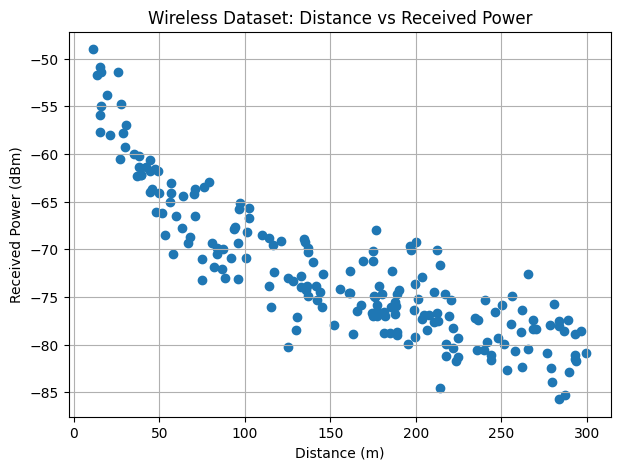

In [ ]:
# ============================================================
# Cell 2: Generate Wireless Regression Dataset
# Predict received power from transmitter-receiver distance
# ============================================================

N = 200

# Distance between transmitter and receiver in meters
distance = np.random.uniform(10, 300, N)

# Simple path-loss inspired model
# Received power decreases as distance increases
received_power = -30 - 20*np.log10(distance) + np.random.normal(0, 3, N)

plt.figure(figsize=(7,5))
plt.scatter(distance, received_power)
plt.xlabel("Distance (m)")
plt.ylabel("Received Power (dBm)")
plt.title("Wireless Dataset: Distance vs Received Power")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# Cell 3: Train/Test Split and Normalization
# ============================================================
print(distance.shape)
print(received_power.shape)
X = distance.reshape(-1, 1)
y = received_power.reshape(-1, 1)
print(X.shape)
print(y.shape)

# Random shuffle
indices = np.random.permutation(N)

train_size = int(0.8 * N)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = torch.tensor(X[train_idx], dtype=torch.float32)
y_train = torch.tensor(y[train_idx], dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
X_test = torch.tensor(X[test_idx], dtype=torch.float32)
y_test = torch.tensor(y[test_idx], dtype=torch.float32)

# Normalize input and output for stable training
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

y_train_n = (y_train - y_mean) / y_std
y_test_n = (y_test - y_mean) / y_std

(200,)
(200,)
(200, 1)
(200, 1)
torch.Size([160, 1])
torch.Size([160, 1])


In [ ]:
# ============================================================
# Cell 4: Linear Regression Model
# ============================================================

linear_model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()

optimizer = optim.Adam(linear_model.parameters(), lr=0.05)

print(linear_model)

Linear(in_features=1, out_features=1, bias=True)


Epoch 0, Loss = 1.2685
Epoch 50, Loss = 0.2317
Epoch 100, Loss = 0.2315
Epoch 150, Loss = 0.2315
Epoch 200, Loss = 0.2315
Epoch 250, Loss = 0.2315


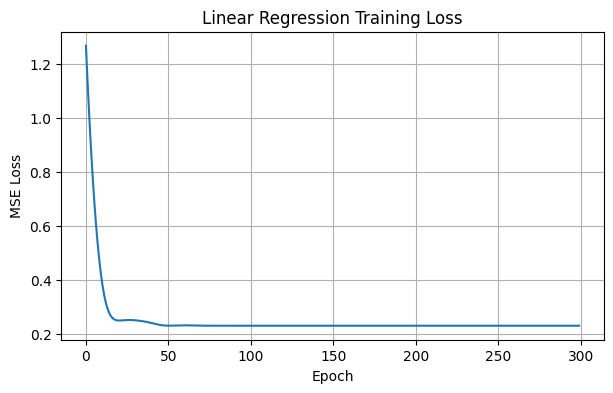

In [ ]:
# ============================================================
# Cell 5: Train Linear Regression Model
# ============================================================

loss_history = []

for epoch in range(300):

    # Forward pass
    y_pred = linear_model(X_train_n)

    # Compute loss
    loss = loss_fn(y_pred, y_train_n)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear Regression Training Loss")
plt.grid()
plt.show()

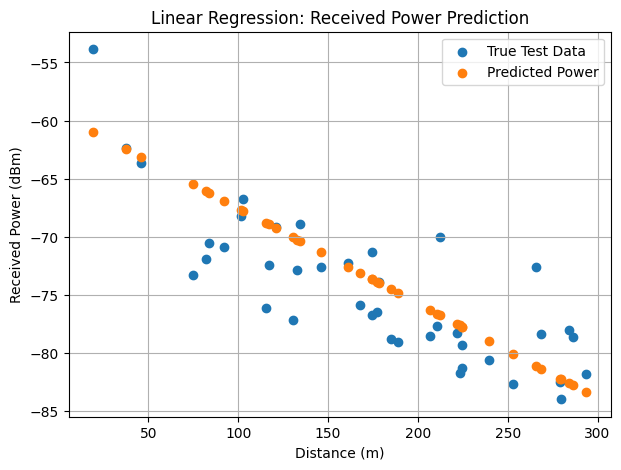

In [ ]:
# ============================================================
# Cell 6: Visualize Linear Regression Result
# ============================================================

with torch.no_grad():
    predicted_n = linear_model(X_test_n)
    predicted_power = predicted_n * y_std + y_mean

plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="True Test Data")
plt.scatter(X_test, predicted_power, label="Predicted Power")
plt.xlabel("Distance (m)")
plt.ylabel("Received Power (dBm)")
plt.title("Linear Regression: Received Power Prediction")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ============================================================
# Cell 7: Try Your Own Distance Input
# ============================================================

def predict_received_power(distance_meter):

    input_tensor = torch.tensor([[distance_meter]], dtype=torch.float32)

    input_n = (input_tensor - X_mean) / X_std

    with torch.no_grad():
        pred_n = linear_model(input_n)
        pred_power = pred_n * y_std + y_mean

    print(f"Input distance: {distance_meter} m")
    print(f"Predicted received power: {pred_power.item():.2f} dBm")

# Try random examples
predict_received_power(50)
predict_received_power(120)
predict_received_power(250)

Input distance: 50 m
Predicted received power: -63.45 dBm
Input distance: 120 m
Predicted received power: -69.17 dBm
Input distance: 250 m
Predicted received power: -79.80 dBm


Logistic Regression Example

Now we classify:

Is the wireless link good or bad?

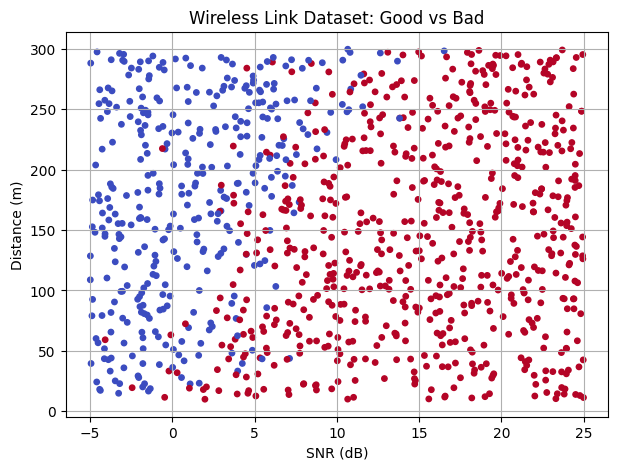

In [ ]:
# ============================================================
# Cell 8: Generate Wireless Link Classification Dataset
# ============================================================

N = 1000

# Features
snr = np.random.uniform(-5, 25, N)
distance = np.random.uniform(10, 300, N)

# Hidden rule: good link if SNR is high and distance is not too large
score = 0.35 * snr - 0.012 * distance + np.random.normal(0, 1, N)

# Label:
# 1 = good link
# 0 = bad link
labels = (score > 0).astype(int)

X = np.column_stack((snr, distance))
y = labels.reshape(-1, 1)

plt.figure(figsize=(7,5))
plt.scatter(snr, distance, c=labels, cmap="coolwarm", s=15)
plt.xlabel("SNR (dB)")
plt.ylabel("Distance (m)")
plt.title("Wireless Link Dataset: Good vs Bad")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# Cell 9: Train/Test Split and Normalization
# ============================================================

indices = np.random.permutation(N)
train_size = int(0.8 * N)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = torch.tensor(X[train_idx], dtype=torch.float32)
y_train = torch.tensor(y[train_idx], dtype=torch.float32)

X_test = torch.tensor(X[test_idx], dtype=torch.float32)
y_test = torch.tensor(y[test_idx], dtype=torch.float32)

X_mean = X_train.mean(dim=0)
X_std = X_train.std(dim=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

In [ ]:
# ============================================================
# Cell 10: Logistic Regression Model
# ============================================================

logistic_model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

loss_fn = nn.BCELoss()

optimizer = optim.Adam(logistic_model.parameters(), lr=0.05)

print(logistic_model)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


Epoch 0, Loss = 0.9817
Epoch 50, Loss = 0.3037
Epoch 100, Loss = 0.2261
Epoch 150, Loss = 0.2010
Epoch 200, Loss = 0.1887
Epoch 250, Loss = 0.1817


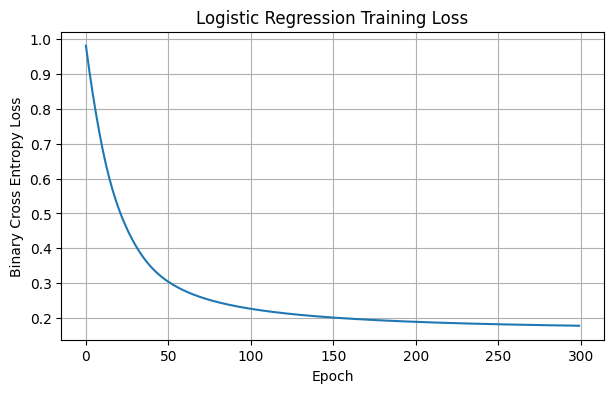

In [ ]:
# ============================================================
# Cell 11: Train Logistic Regression
# ============================================================

loss_history = []

for epoch in range(300):

    probs = logistic_model(X_train_n)

    loss = loss_fn(probs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# Cell 12: Evaluate Classification Accuracy
# ============================================================

with torch.no_grad():

    probs = logistic_model(X_test_n)

    predictions = (probs > 0.5).float()

    accuracy = (predictions == y_test).float().mean()

print(f"Test Accuracy: {accuracy.item()*100:.2f}%")

Test Accuracy: 93.00%


In [ ]:
# ============================================================
# Cell 13: Try Your Own Wireless Link Input
# ============================================================

def predict_link_quality(snr_db, distance_meter):

    input_data = torch.tensor([[snr_db, distance_meter]], dtype=torch.float32)

    input_n = (input_data - X_mean) / X_std

    with torch.no_grad():
        probability = logistic_model(input_n).item()

    predicted_class = "Good Link" if probability > 0.5 else "Bad Link"

    print(f"SNR: {snr_db} dB")
    print(f"Distance: {distance_meter} m")
    print(f"Probability of Good Link: {probability:.3f}")
    print(f"Prediction: {predicted_class}")

# Try examples
predict_link_quality(20, 50)
predict_link_quality(5, 200)
predict_link_quality(15, 150)

SNR: 20 dB
Distance: 50 m
Probability of Good Link: 1.000
Prediction: Good Link
SNR: 5 dB
Distance: 200 m
Probability of Good Link: 0.243
Prediction: Bad Link
SNR: 15 dB
Distance: 150 m
Probability of Good Link: 0.986
Prediction: Good Link


#Activation Functions and Optimizers

In [ ]:
# ============================================================
# Cell 14: Neural Network with Different Activation Functions
# ============================================================

class WirelessNN(nn.Module):

    def __init__(self, activation="relu"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "sigmoid":
            act = nn.Sigmoid()
        elif activation == "tanh":
            act = nn.Tanh()
        else:
            raise ValueError("Choose: relu, sigmoid, or tanh")

        self.net = nn.Sequential(
            nn.Linear(2, 16),
            act,
            nn.Linear(16, 16),
            act,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

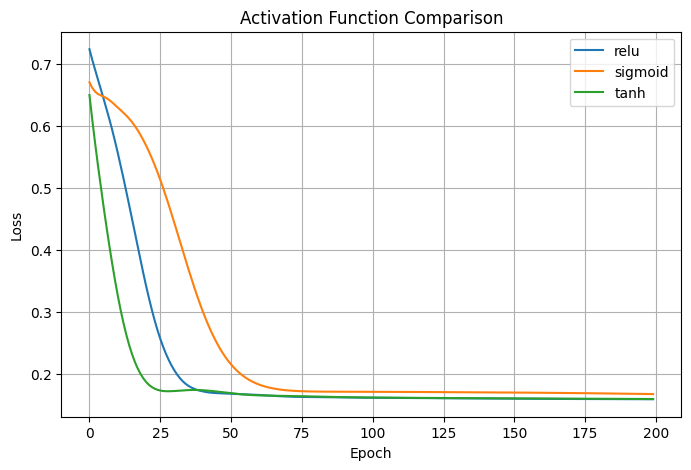

relu accuracy = 93.00%
sigmoid accuracy = 93.50%
tanh accuracy = 92.00%


In [ ]:
# ============================================================
# Cell 15: Compare ReLU, Sigmoid, and Tanh
# ============================================================

activations = ["relu", "sigmoid", "tanh"]

activation_results = {}

for activation in activations:

    model = WirelessNN(activation)

    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    losses = []

    for epoch in range(200):

        probs = model(X_train_n)

        loss = loss_fn(probs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    with torch.no_grad():
        probs = model(X_test_n)
        preds = (probs > 0.5).float()
        acc = (preds == y_test).float().mean().item()

    activation_results[activation] = {
        "losses": losses,
        "accuracy": acc
    }

plt.figure(figsize=(8,5))

for activation in activations:
    plt.plot(activation_results[activation]["losses"], label=activation)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Activation Function Comparison")
plt.legend()
plt.grid()
plt.show()

for activation in activations:
    print(f"{activation} accuracy = {activation_results[activation]['accuracy']*100:.2f}%")

| Optimizer | Main Idea                        |
| --------- | -------------------------------- |
| SGD       | basic gradient descent           |
| Momentum  | smoother SGD                     |
| RMSProp   | adaptive learning rate           |
| Adam      | momentum + RMSProp               |
| AdamW     | Adam with better regularization  |
| Adagrad   | larger updates for rare features |
| Adadelta  | improved Adagrad                 |
| NAdam     | Adam + Nesterov momentum         |


optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

optimizer = optim.RMSprop(model.parameters(), lr=0.001)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
optimizer = optim.Adagrad(model.parameters(), lr=0.01)
optimizer = optim.Adadelta(model.parameters(), lr=1.0)
optimizers = {
    "SGD": optim.SGD(model.parameters(), lr=0.01),
    "Momentum": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
    "RMSProp": optim.RMSprop(model.parameters(), lr=0.001),
    "Adam": optim.Adam(model.parameters(), lr=0.001),
    "AdamW": optim.AdamW(model.parameters(), lr=0.001)
}



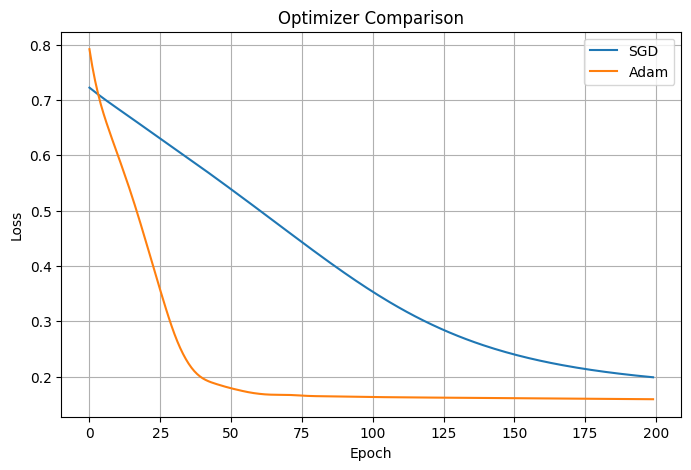

SGD accuracy = 91.00%
Adam accuracy = 92.50%


In [ ]:
# ============================================================
# Cell 16: Compare SGD and Adam Optimizers
# ============================================================

optimizer_names = ["SGD", "Adam"]

optimizer_results = {}

for opt_name in optimizer_names:

    model = WirelessNN("relu")

    loss_fn = nn.BCELoss()

    if opt_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.05)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.01)

    losses = []

    for epoch in range(200):

        probs = model(X_train_n)

        loss = loss_fn(probs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    with torch.no_grad():
        probs = model(X_test_n)
        preds = (probs > 0.5).float()
        acc = (preds == y_test).float().mean().item()

    optimizer_results[opt_name] = {
        "losses": losses,
        "accuracy": acc
    }

plt.figure(figsize=(8,5))

for opt_name in optimizer_names:
    plt.plot(optimizer_results[opt_name]["losses"], label=opt_name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()

for opt_name in optimizer_names:
    print(f"{opt_name} accuracy = {optimizer_results[opt_name]['accuracy']*100:.2f}%")

Try different Loss function:
| Loss Function       | Used For                               |
| ------------------- | -------------------------------------- |
| MSELoss             | regression                             |
| L1Loss              | regression                             |
| CrossEntropyLoss    | multi-class classification             |
| BCELoss             | binary classification                  |
| BCEWithLogitsLoss   | binary classification (better version) |
| NLLLoss             | classification                         |
| HingeEmbeddingLoss  | SVM-style learning                     |
| KLDivLoss           | probability distributions              |
| SmoothL1Loss        | robust regression                      |
| CosineEmbeddingLoss | similarity learning                    |


In [ ]:
# ============================================================
# Cell 17: Student Challenge
# ============================================================

print("""
Student Challenges:

1. Change the SNR range from (-5, 25) to (-15, 15).
   What happens to classification accuracy?

2. Change the distance range from (10, 300) to (10, 600).
   Is the wireless link harder to classify?

3. Change the activation function.
   Which one learns fastest?

4. Compare SGD and Adam.
   Which optimizer converges faster?

5. Try your own input:
   predict_link_quality(?, ?)

6. Explain:
   Why does linear regression output a number,
   but logistic regression outputs a probability?
""")


Student Challenges:

1. Change the SNR range from (-5, 25) to (-15, 15).
   What happens to classification accuracy?

2. Change the distance range from (10, 300) to (10, 600).
   Is the wireless link harder to classify?

3. Change the activation function.
   Which one learns fastest?

4. Compare SGD and Adam.
   Which optimizer converges faster?

5. Try your own input:
   predict_link_quality(?, ?)

6. Explain:
   Why does linear regression output a number,
   but logistic regression outputs a probability?



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)
np.random.seed(0)


DNN example

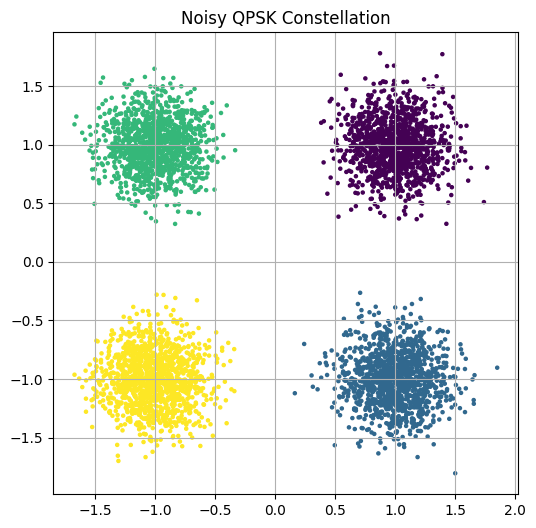

In [ ]:
# ============================================================
# Generate QPSK Wireless Dataset
# ============================================================

N = 5000

constellation = {
    0: 1+1j,
    1: 1-1j,
    2: -1+1j,
    3: -1-1j
}

labels = np.random.randint(0, 4, N)

symbols = np.array([constellation[l] for l in labels])

snr_db = 10
snr_linear = 10**(snr_db/10)

noise = (np.random.randn(N) + 1j*np.random.randn(N)) / np.sqrt(2*snr_linear)

rx = symbols + noise

X = np.column_stack((rx.real, rx.imag))
y = labels

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, s=5)
plt.title("Noisy QPSK Constellation")
plt.grid(True)
plt.show()


In [ ]:

# ============================================================
# DNN Classifier
# ============================================================

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 4)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(50):

    optimizer.zero_grad()

    outputs = model(X_tensor)

    loss = criterion(outputs, y_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())


0 1.4947223663330078
10 0.31308668851852417
20 0.04568490386009216
30 0.012026128359138966
40 0.005884817335754633


In [ ]:
import pandas as pd

# Get predictions for the first 10 samples
with torch.no_grad():
    raw_outputs = model(X_tensor[:10])
    predictions = torch.argmax(raw_outputs, dim=1)

# Create a comparison table
sample_comparison = pd.DataFrame({
    'Transmitted Label': y[:10],
    'Predicted Label': predictions.numpy(),
    'Correct?': y[:10] == predictions.numpy()
})

print("Sample Comparison (First 10 symbols):")
display(sample_comparison)

Sample Comparison (First 10 symbols):


,Transmitted Label,Predicted Label,Correct?
0,0,0,True
1,3,3,True
2,1,1,True
3,0,0,True
4,3,3,True
5,3,3,True
6,3,3,True
7,3,3,True
8,1,1,True
9,3,3,True


In [ ]:
print(X_tensor[:1],y[:1],raw_outputs[1]) # 4 outputs, the last one is largest and show class three
probabilities = torch.softmax(raw_outputs, dim=1)
print(probabilities)

tensor([[0.9036, 0.6743]]) [0] tensor([-6.0729, -2.3217, -2.6525,  4.9833])
tensor([[9.9180e-01, 5.1801e-03, 2.7316e-03, 2.9235e-04],
        [1.5770e-05, 6.7137e-04, 4.8226e-04, 9.9883e-01],
        [3.2229e-03, 9.9619e-01, 1.7817e-04, 4.0873e-04],
        [9.9741e-01, 2.1658e-03, 3.7983e-04, 4.7450e-05],
        [1.7956e-05, 3.0226e-04, 2.6758e-03, 9.9700e-01],
        [1.1099e-06, 5.2990e-05, 8.1176e-05, 9.9986e-01],
        [6.2341e-06, 7.3948e-04, 9.5367e-05, 9.9916e-01],
        [1.3314e-05, 2.0896e-04, 2.8382e-03, 9.9694e-01],
        [4.5639e-04, 9.9931e-01, 4.6146e-05, 1.8813e-04],
        [1.7031e-05, 1.5506e-03, 2.4190e-04, 9.9819e-01]])



# CNN Activity (Instructor Demo)

Students observe how CNNs can estimate channels from OFDM resource grids.

Discussion:
- Why CNN works on wireless channels
- Spatial correlation
- Pilot interpolation
- Feature extraction


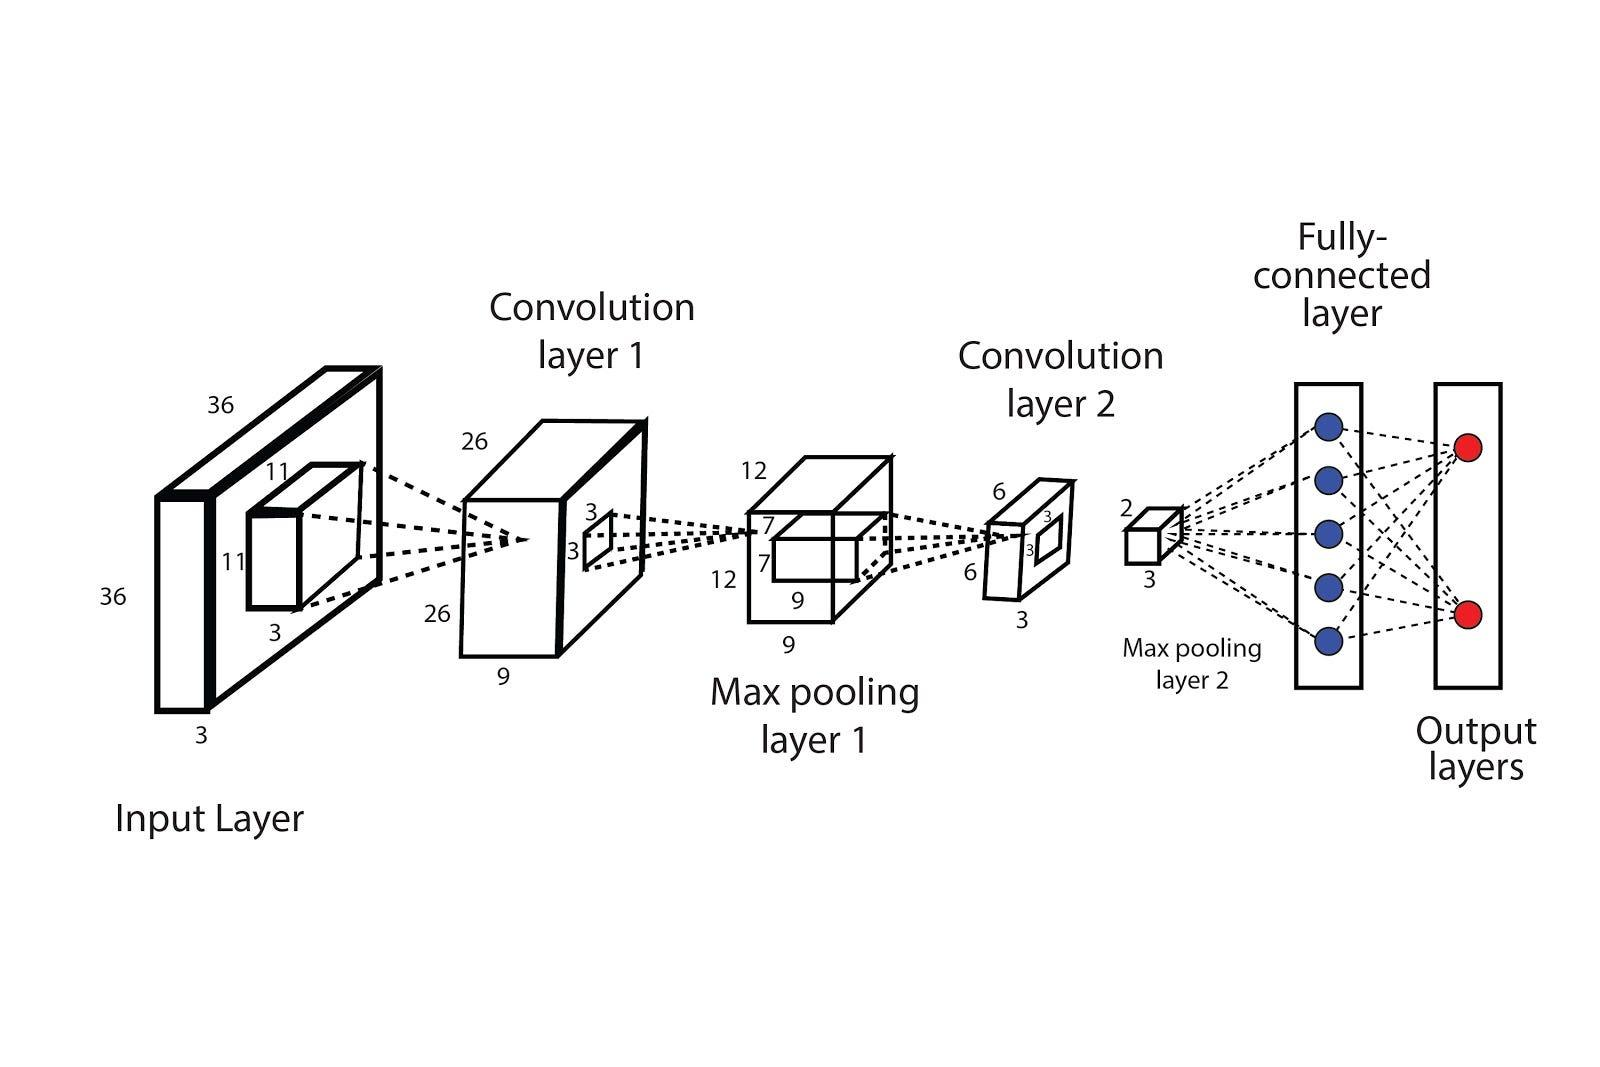

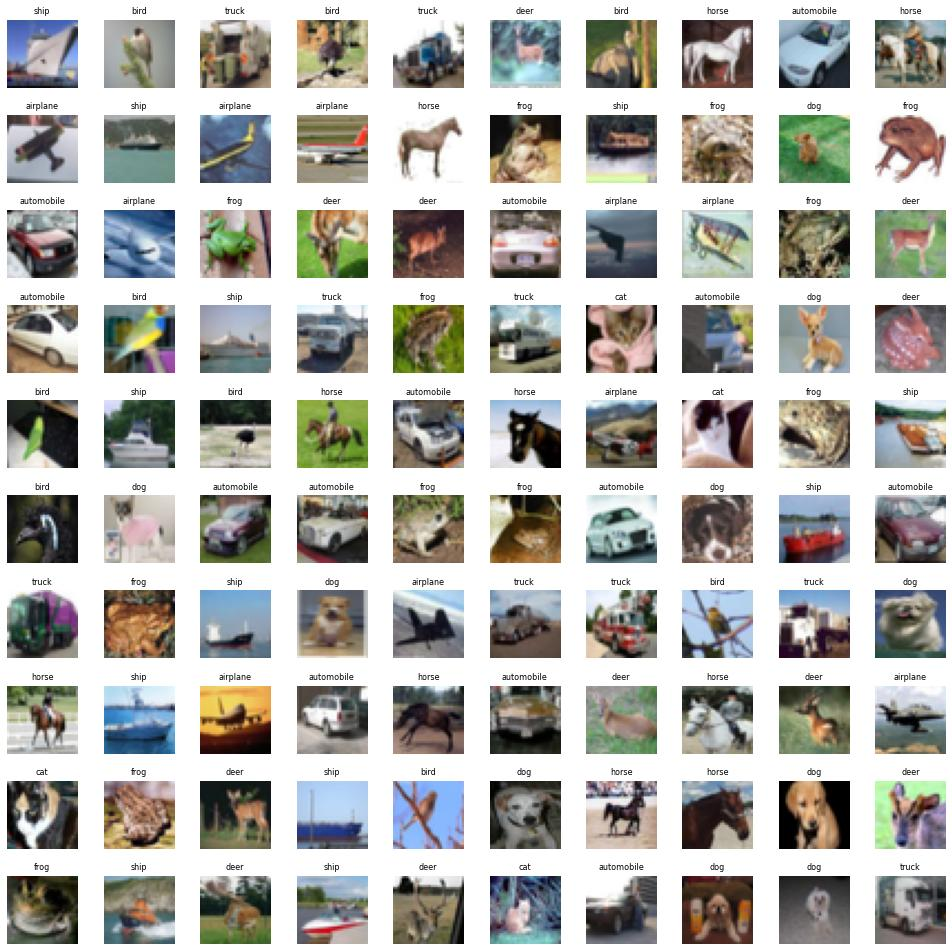

| Property        | Value   |
| --------------- | ------- |
| Total images    | 60,000  |
| Training images | 50,000  |
| Test images     | 10,000  |
| Classes         | 10      |
| Image size      | 32 × 32 |
| Channels        | 3 (RGB) |
| Class Number | Class Name |
| ------------ | ---------- |
| 0            | airplane   |
| 1            | automobile |
| 2            | bird       |
| 3            | cat        |
| 4            | deer       |
| 5            | dog        |
| 6            | frog       |
| 7            | horse      |
| 8            | ship       |
| 9            | truck      |


100%|██████████| 170M/170M [00:02<00:00, 71.5MB/s]


Epoch 1, Loss = 1231.105
Epoch 2, Loss = 977.954
Epoch 3, Loss = 876.509
Epoch 4, Loss = 801.292
Epoch 5, Loss = 736.923
Epoch 6, Loss = 687.909
Epoch 7, Loss = 646.238
Epoch 8, Loss = 601.563
Epoch 9, Loss = 567.809
Epoch 10, Loss = 532.603
Accuracy of the network on the 10000 test images: 68.28%


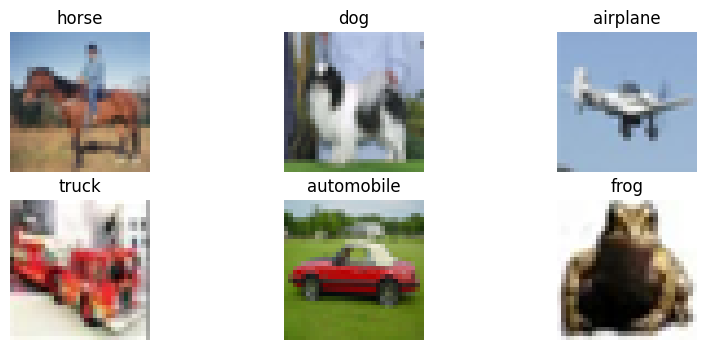

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load CIFAR-10 Dataset
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

# ------------------------------------------------------------
# 2. Define CNN Model
# ------------------------------------------------------------

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=3,   # RGB image
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # Conv1 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv1(x)))

        # Conv2 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x)))

        # Flatten tensor
        x = x.view(x.size(0), -1)

        # Fully connected
        x = torch.relu(self.fc1(x))

        # Final output
        x = self.fc2(x)

        return x

# ------------------------------------------------------------
# 3. Create Model
# ------------------------------------------------------------

model = SimpleCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ------------------------------------------------------------
# 4. Training Loop
# ------------------------------------------------------------

num_epochs = 10 # Increased number of epochs

for epoch in range(num_epochs):

    running_loss = 0

    for images, labels in trainloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss = {running_loss:.3f}")

# ------------------------------------------------------------
# 5. Evaluate Model Accuracy
# ------------------------------------------------------------
model.eval() # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad(): # Disable gradient calculation for inference
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

# ------------------------------------------------------------
# 6. Display Example Images
# ------------------------------------------------------------

classes = trainset.classes

images, labels = next(iter(trainloader))

plt.figure(figsize=(10,4))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0).numpy()

    plt.imshow(img)

    plt.title(classes[labels[i]])

    plt.axis('off')

plt.show()


# GAN Mini Demo

Students visualize:
- Real channel samples
- Fake generated channel samples

Discussion:
- Synthetic wireless data generation
- Channel modeling
- Data augmentation



# Attention & Transformer Activity

Students discuss:
- Why sequence models matter
- Time-varying channels
- CSI feedback
- Attention mechanism

Mini challenge:
How could transformers replace classical equalizers?



# Score-Based Generative Models

Instructor concept demo:
- Noise-to-signal generation
- Diffusion intuition
- Wireless channel synthesis

Discussion:
Why are diffusion/score models becoming important?



# End of Lab Challenge

Students modify:
1. SNR values
2. Hidden layer size
3. Number of epochs

Questions:
- What happens to accuracy?
- When does DNN fail?
- Why is wireless data difficult?
- Which model seems most promising?
